# 04 — Demand Forecasting: LightGBM

Weekly order volume forecast by Brazilian state and product category.

**Contents:**
1. Demand series exploration
2. Seasonality decomposition
3. Top states and categories
4. Train with walk-forward CV
5. Forecast visualisation (p10/p50/p90)
6. Feature importance

In [5]:
import sys, os
# Make project root importable regardless of where Jupyter is launched from
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to path ✓")

Project root added to path ✓


In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
import mlflow

from data_loader import OlistLoader
from ml.demand_forecast_model import DemandForecastModel

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.figsize"] = (14, 5)
sns.set_theme(style="darkgrid")

loader = OlistLoader()
demand = loader.demand_series()

print(f"Demand series shape: {demand.shape}")
print(f"Date range: {demand['week_start'].min().date()} → {demand['week_start'].max().date()}")
print(f"States:     {demand['customer_state'].nunique()}")
print(f"Categories: {demand['category'].nunique()}")

2026-03-06 21:06:19.616 | INFO     | data_loader:__init__:65 - OlistLoader ready — 9/9 CSV files found in C:\Users\luizg\Downloads\ProjetoGithub\olist-ecommerce-platform\data
2026-03-06 21:06:19.617 | INFO     | data_loader:order_features:129 - Building order_features table...
2026-03-06 21:06:19.958 | DEBUG    | data_loader:_read:296 - Loaded orders: 99,441 rows from olist_orders_dataset.csv
2026-03-06 21:06:20.371 | DEBUG    | data_loader:_read:296 - Loaded order_items: 112,650 rows from olist_order_items_dataset.csv
2026-03-06 21:06:20.474 | DEBUG    | data_loader:_read:296 - Loaded order_payments: 103,886 rows from olist_order_payments_dataset.csv
2026-03-06 21:06:20.774 | DEBUG    | data_loader:_read:296 - Loaded order_reviews: 99,224 rows from olist_order_reviews_dataset.csv
2026-03-06 21:06:20.952 | DEBUG    | data_loader:_read:296 - Loaded customers: 99,441 rows from olist_customers_dataset.csv
2026-03-06 21:06:20.958 | DEBUG    | data_loader:_read:296 - Loaded sellers: 3,095 r

Demand series shape: (25902, 4)
Date range: 2016-09-12 → 2018-08-27
States:     27
Categories: 72


## 1. National Weekly Demand

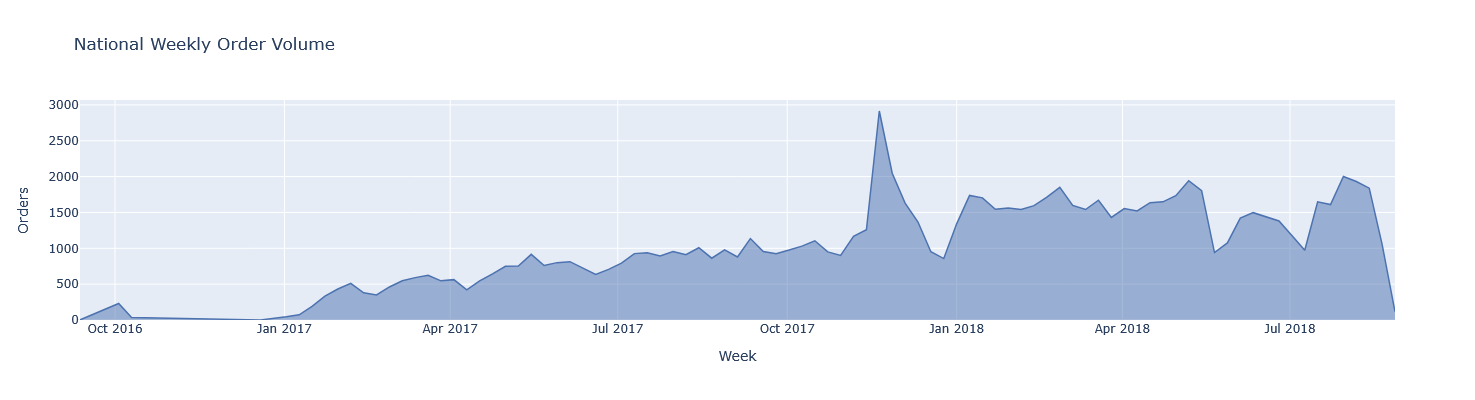

Peak week:  2017-11-20  (2,915 orders)


In [7]:
national = demand.groupby("week_start")["order_count"].sum().reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=national["week_start"], y=national["order_count"],
    fill="tozeroy", name="Weekly Orders",
    line=dict(color="#4C72B0", width=1.5),
))
fig.update_layout(
    title="National Weekly Order Volume",
    xaxis_title="Week", yaxis_title="Orders", height=400,
)
fig.show()

print(f"Peak week:  {national.loc[national['order_count'].idxmax(), 'week_start'].date()}  ({national['order_count'].max():,} orders)")

## 2. Seasonality Decomposition

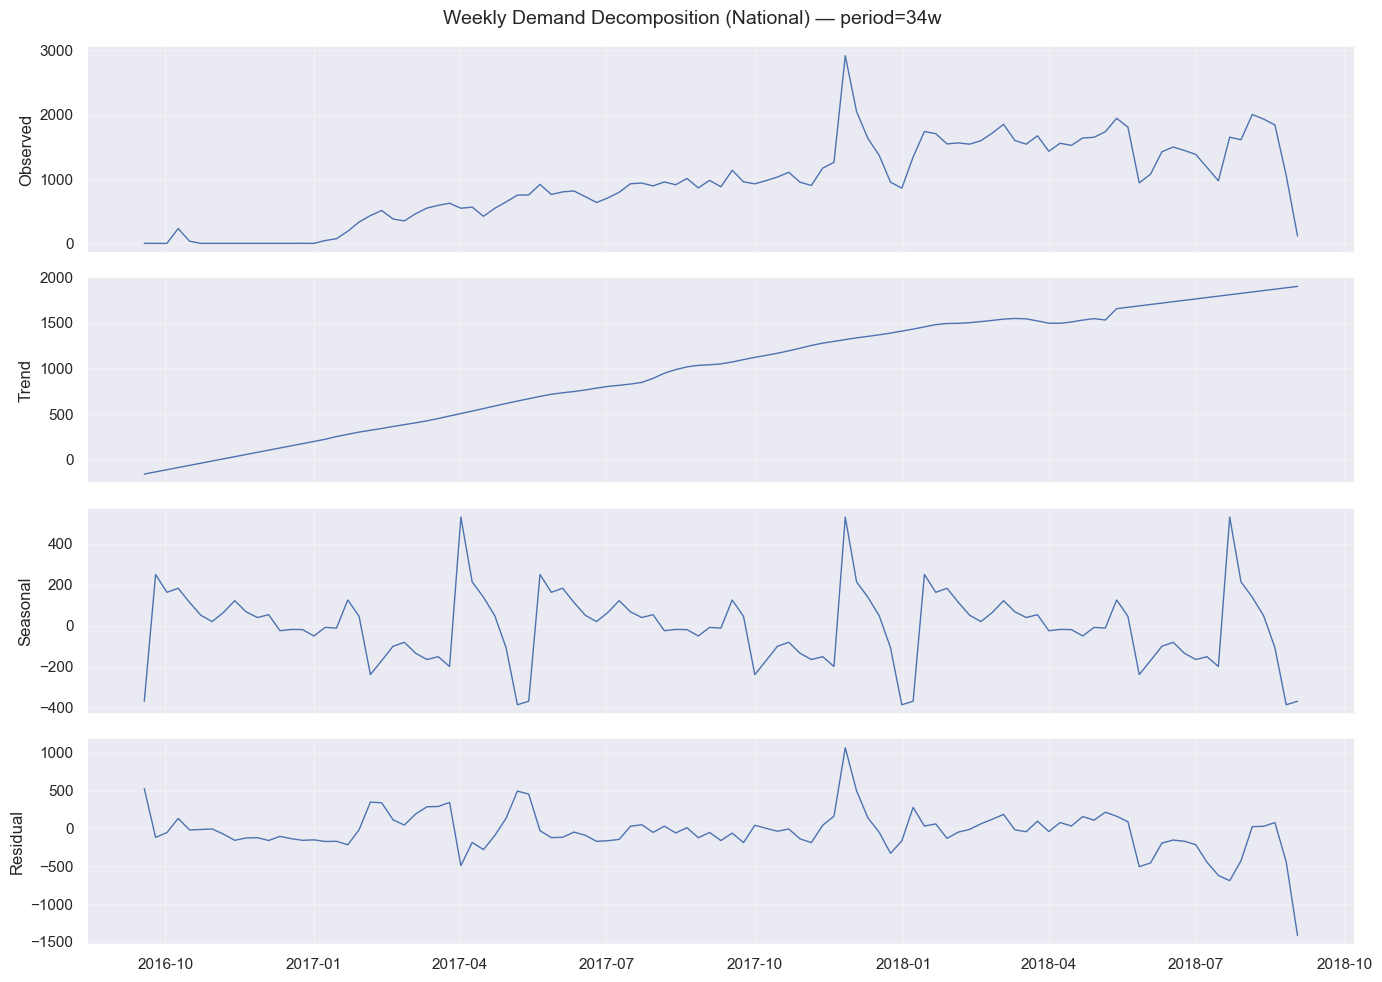

In [8]:
# Resample to a complete weekly grid first — demand_series() only has weeks
# where orders actually occurred, so gap weeks are missing. pandas refuses
# to assign freq="W" to an irregular index, and seasonal_decompose requires
# a gapless series.
national_ts = (
    national.set_index("week_start")["order_count"]
    .resample("W")          # fills missing weeks
    .sum()                  # weeks with no orders → 0
    .fillna(0)
)

# seasonal_decompose needs at least 2 full cycles; with period=52 that means
# 104 weeks minimum. If the dataset is shorter, use a smaller period.
n_weeks = len(national_ts)
period  = 52 if n_weeks >= 104 else max(4, n_weeks // 3)

decomp = seasonal_decompose(national_ts, model="additive", period=period,
                             extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (label, component) in zip(axes, [
    ("Observed",  decomp.observed),
    ("Trend",     decomp.trend),
    ("Seasonal",  decomp.seasonal),
    ("Residual",  decomp.resid),
]):
    ax.plot(component, linewidth=1)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Weekly Demand Decomposition (National) — period={period}w", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Top States & Categories

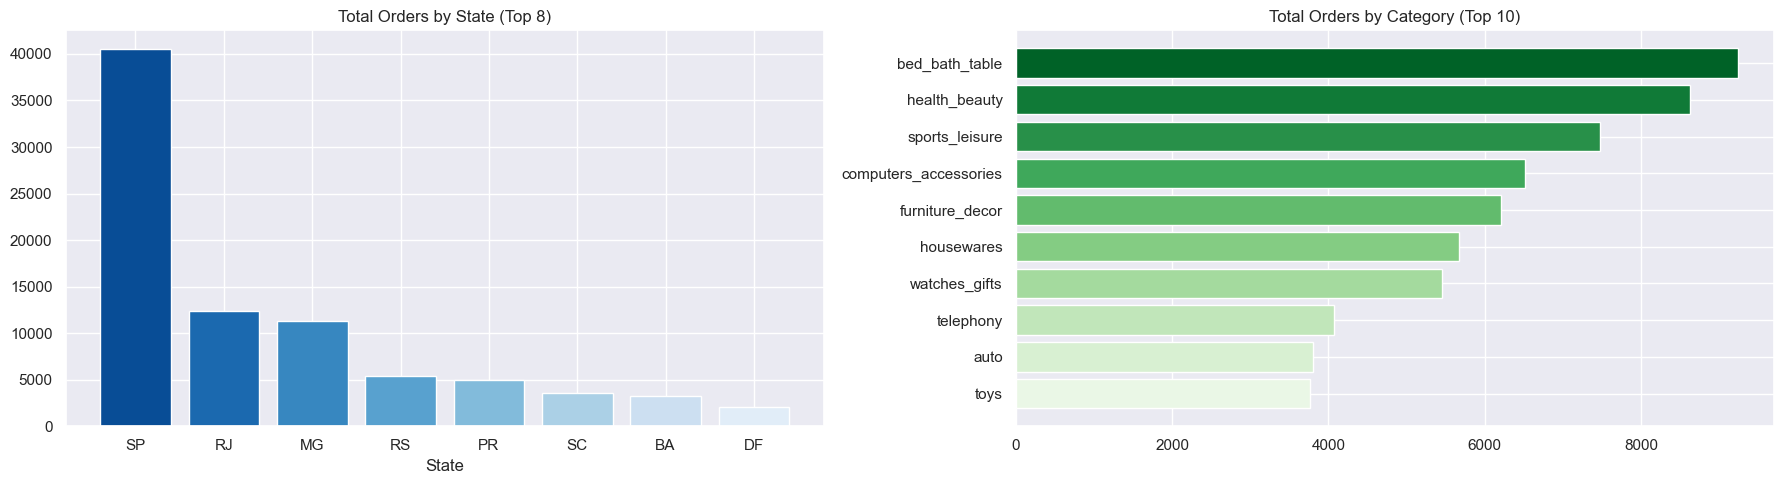

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

top_states = demand.groupby("customer_state")["order_count"].sum().sort_values(ascending=False).head(8)
axes[0].bar(top_states.index, top_states.values, color=sns.color_palette("Blues_r", 8))
axes[0].set_title("Total Orders by State (Top 8)")
axes[0].set_xlabel("State")

top_cats = demand.groupby("category")["order_count"].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_cats.index, top_cats.values, color=sns.color_palette("Greens_r", 10))
axes[1].set_title("Total Orders by Category (Top 10)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Train Model & Walk-Forward CV

In [10]:

forecast_model = DemandForecastModel(forecast_horizon=4, n_splits=5)
forecast       = forecast_model.train_and_forecast(demand)

print(f"Forecast rows: {len(forecast):,}")
print(forecast.head(8).to_string(index=False))

2026-03-06 21:06:41.425 | INFO     | ml.demand_forecast_model:train_and_forecast:91 - Demand series — 25,902 rows  2016-09-12 → 2018-08-27
2026/03/06 21:06:43 INFO mlflow.tracking.fluent: Experiment with name 'olist/demand-forecast' does not exist. Creating a new experiment.
2026-03-06 21:08:08.934 | INFO     | ml.demand_forecast_model:train_and_forecast:111 - CV — MAE: 0.37  MAPE: 9781491.94%
2026-03-06 21:08:10.619 | INFO     | ml.demand_forecast_model:_train_final:314 - Trained p10 quantile model ✓
2026-03-06 21:08:12.180 | INFO     | ml.demand_forecast_model:_train_final:314 - Trained p50 quantile model ✓
2026-03-06 21:08:13.624 | INFO     | ml.demand_forecast_model:_train_final:314 - Trained p90 quantile model ✓
2026-03-06 21:15:22.205 | INFO     | ml.demand_forecast_model:_save:371 - Model saved to ml\artifacts\demand_forecast_model.pkl
2026-03-06 21:15:22.206 | INFO     | ml.demand_forecast_model:train_and_forecast:121 - Forecast complete — 7,776 rows × 4 weeks ahead


🏃 View run demand_forecast_lgbm at: http://localhost:5000/#/experiments/0/runs/4a77f9ff5ed84987a705152094e36dfc
🧪 View experiment at: http://localhost:5000/#/experiments/0
Forecast rows: 7,776
customer_state                   category forecast_date  forecast_week  forecast_p10  forecast_p50  forecast_p90
            AC agro_industry_and_commerce    2018-09-03              1          0.00          0.00          0.00
            AC           air_conditioning    2018-09-03              1          0.00          0.00          0.00
            AC                        art    2018-09-03              1          0.00          0.00          0.00
            AC      arts_and_craftmanship    2018-09-03              1          0.00          0.00          0.00
            AC                      audio    2018-09-03              1          0.00          0.00          0.00
            AC                       auto    2018-09-03              1          0.00          0.00          0.00
            AC  

## 5. Forecast Visualisation

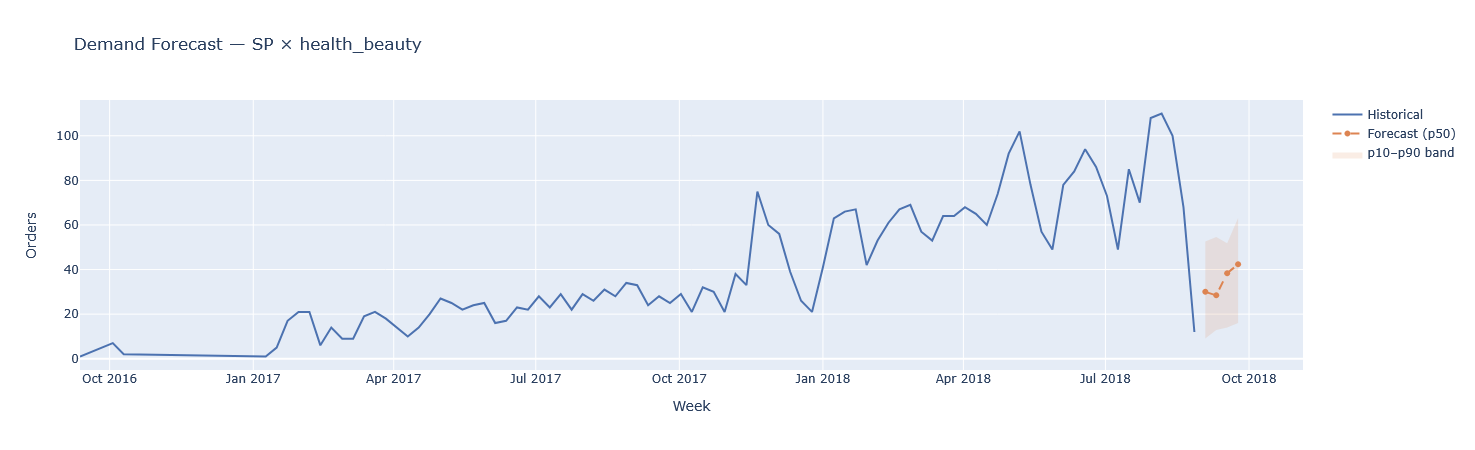

In [11]:
# Change state/cat to explore other combinations
state, cat = "SP", "health_beauty"

hist  = demand[(demand["customer_state"] == state) & (demand["category"] == cat)].sort_values("week_start")
fcast = forecast[(forecast["customer_state"] == state) & (forecast["category"] == cat)]

if len(hist) > 0:
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=hist["week_start"], y=hist["order_count"],
        name="Historical", line=dict(color="#4C72B0"),
    ))
    if len(fcast) > 0:
        fig.add_trace(go.Scatter(
            x=fcast["forecast_date"], y=fcast["forecast_p50"],
            name="Forecast (p50)", line=dict(color="#DD8452", dash="dash"),
        ))
        fig.add_trace(go.Scatter(
            x=pd.concat([fcast["forecast_date"], fcast["forecast_date"].iloc[::-1]]),
            y=pd.concat([fcast["forecast_p90"], fcast["forecast_p10"].iloc[::-1]]),
            fill="toself", fillcolor="rgba(221,132,82,0.15)",
            line=dict(color="rgba(0,0,0,0)"), name="p10–p90 band",
        ))
    fig.update_layout(
        title=f"Demand Forecast — {state} × {cat}",
        xaxis_title="Week", yaxis_title="Orders", height=450,
    )
    fig.show()
else:
    print(f"No data for {state} × {cat}")

## 6. Feature Importance

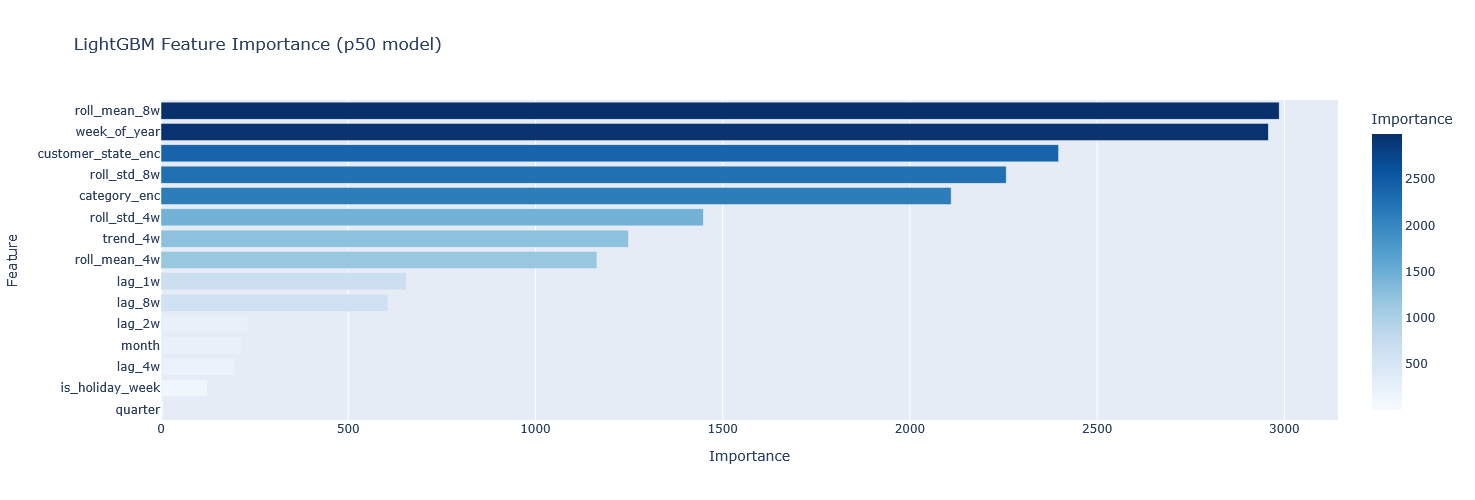


Top 5 features:
           feature  importance
      roll_mean_8w        2986
      week_of_year        2957
customer_state_enc        2397
       roll_std_8w        2257
      category_enc        2110


In [12]:
imp = forecast_model.top_features(quantile="p50", n=15)

import plotly.express as px
fig = px.bar(
    imp, x="importance", y="feature", orientation="h",
    title="LightGBM Feature Importance (p50 model)",
    labels={"importance": "Importance", "feature": "Feature"},
    color="importance", color_continuous_scale="Blues",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"}, height=500, showlegend=False)
fig.show()

print("\nTop 5 features:")
print(imp.head().to_string(index=False))